# Monetary IRFs from US Data

This code imports FRED data for monetary policy IRFs with US data and then analyzes IRFs for a monetary policy shock using VAR, LP, and SLP. The variables used are the [federal funds effective rate](https://fred.stlouisfed.org/series/DFF#), [real GDP](https://fred.stlouisfed.org/series/GDPC1), and [personal consumption expenditures](https://fred.stlouisfed.org/series/DPCCRV1Q225SBEA). Data is from Jan 2012 - Oct 2025.

In [1]:
import sys
sys.path.append("..")

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.api import VAR
from slp.estimators import SmoothLocalProjections
from slp.results import LPResults, SLPResults

In [2]:
# set parameter
q = 12 # IRF forecast horizon - must be greater than 7 or SLP is poorly conditioned

In [3]:
# Helper function to plot IRFs
def plot_irf_combined(var, LP, SLP):
    varnames = ['GDP growth', 'Inflation', 'Federal funds rate']
    methods = {
        'VAR':   (var,      'gray', 'D'),
        'LP':    (LP,       '#1565C0', '^'), 
        'SLP':   (SLP,      '#DC143C', 's'),
    }
    horizons = range(var.shape[0])
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for i, ax in enumerate(axes):
        for label, (data, color, marker) in methods.items():
            ax.plot(horizons, data.iloc[:, i], color=color, marker=marker,
                    markersize=5, linewidth=1.4, label=label)
        ax.axhline(0, color='black', linestyle='dashed', linewidth=0.8)
        ax.set_title(f'Federal funds rate → {varnames[i]}')
        ax.set_xlabel('Quarters')
        ax.set_ylabel('Response')
        ax.legend(fontsize=8)
    fig.suptitle('Impulse Response Functions to FFR Shock', fontsize=13)
    plt.tight_layout()
    plt.show()

### Loading, processing, and visualizing data

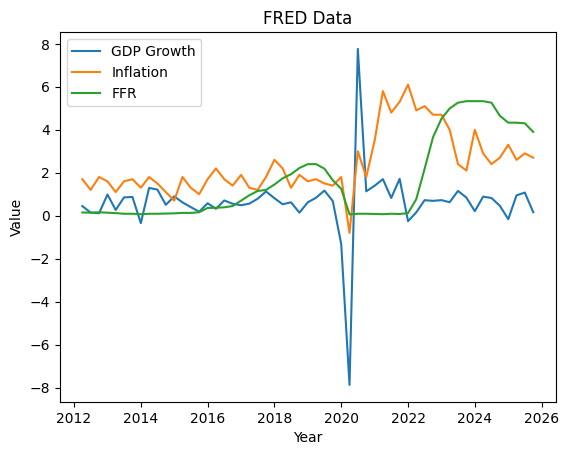

In [4]:
# Load data
gdp = pd.read_csv('../example_notebooks/data/GDPC1.csv', index_col = 0, parse_dates = True)
pce = pd.read_csv('../example_notebooks/data/DPCCRV1Q225SBEA.csv', index_col = 0, parse_dates = True)
ffr = pd.read_csv('../example_notebooks/data/DFF.csv', index_col = 0, parse_dates = True)

# Merge data into one dataframe
data = pd.concat([gdp, pce, ffr], axis=1)
data.columns = ['GDP','Inflation', 'FFR']

# GDP growth rate
data['GDP'] = data['GDP'].pct_change() * 100
data = data.dropna() # removes first observations (missing differences)

# pPlot observed time series
plt.plot(data)
plt.title("FRED Data")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend(["GDP Growth", "Inflation", "FFR"])
plt.show()

### Estimating impulse responses

In [5]:
# VAR estimation of IRFs
var_mod = VAR(data)
opt_lags = var_mod.select_order(maxlags = 10).aic
var_fit = var_mod.fit(opt_lags)
var_irfs = var_fit.irf(periods = q).irfs
var_beta = pd.DataFrame(var_irfs[:,:,2])

# LP/SLP estimation of IRFs
LP_mod = SmoothLocalProjections(data, shock = "FFR", endog = None, shock_exo = False, p = opt_lags, H = q)
LP_fit = LP_mod.LP()
SLP_fit = LP_mod.SLP(n_knots = 5, lam = 0.5, r = 2)

LP_beta = pd.DataFrame(LP_fit.beta)
SLP_beta = pd.DataFrame(SLP_fit.beta)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


### Results

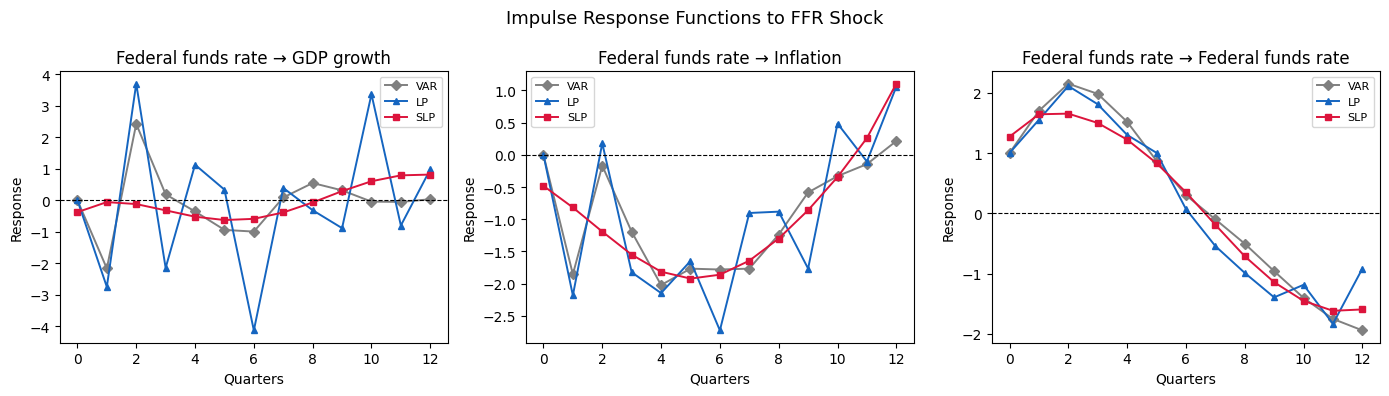

In [6]:
plot_irf_combined(var_beta, LP_beta, SLP_beta)

### Discussion
Without knowledge of the underlying DGP it is impossible to compare the accuracy of these estimation strategies, but a few observations can be made. In all cases the response of inflation to an increase in the interest rate is negative, as theory predicts. VAR and LP estimates are both jagged, particularly LP, showing enormous fluctuations in impact that seem unlikely to be true, whereas the SLP estimate is much smoother. Interestingly, LP and SLP estimates have a strong positive inflation response by quarter 12, whereas the VAR estimate does not. The estimated response of the interest rate is very similar across all three approaches, although LP becomes quite jagged at the end. 

The three estimation strategies differ considerably in the GDP growth response: VAR displays oscillation around zero with diminishing amplitude, LP shows oscillation around zero with no indication of diminishing, and SLP shows an initial drop followed by an increase and larger positive response. Most literature and theory suggests that monetary policy has no long-term effects on GDP growth, consistent with the VAR model. The magnitude of GDP growth response also differs considerably between the three approaches: VAR estimates are between -3 and 3 percentage points, LP estimates are between -5 and 4, and SLP is bounded by -1 and 1. Without knowledge of the DGP no conclusions can be drawn, but the magnitude of response estimated by LP seems unlikely.

### Data Citations
Board of Governors of the Federal Reserve System (US), Federal Funds Effective Rate [DFF], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/DFF, April 4, 2026.

U.S. Bureau of Economic Analysis, Personal Consumption Expenditures (PCE) Excluding Food and Energy (Chain-Type Price Index) [DPCCRV1Q225SBEA], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/DPCCRV1Q225SBEA, April 4, 2026.

U.S. Bureau of Economic Analysis, Real Gross Domestic Product [GDPC1], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/GDPC1, April 4, 2026.